11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Unique labels: {np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9)}


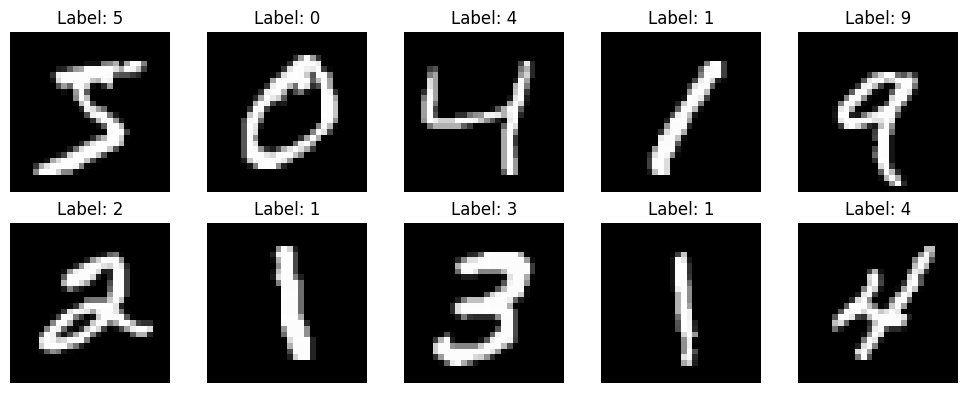

In [1]:
# --- Load and inspect the MNIST dataset ---
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Print shapes
print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)
print("Unique labels:", set(y_train))

# Visualize some samples
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


In [2]:
# --- Preprocessing for Fully Connected Network ---
from tensorflow.keras.utils import to_categorical

# Flatten images (28x28 -> 784)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Normalize pixel values (0–255 -> 0–1)
X_train_flat = X_train_flat / 255.0
X_test_flat = X_test_flat / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("X_train_flat shape:", X_train_flat.shape)
print("y_train_cat shape:", y_train_cat.shape)


X_train_flat shape: (60000, 784)
y_train_cat shape: (60000, 10)


In [3]:
# --- Fully Connected Neural Network ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define model
fc_model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile
fc_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history_fc = fc_model.fit(
    X_train_flat, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=2
)

# Evaluate
test_loss_fc, test_acc_fc = fc_model.evaluate(X_test_flat, y_test_cat, verbose=0)
print(f"✅ Fully Connected Network Test Accuracy: {test_acc_fc:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
375/375 - 3s - 8ms/step - accuracy: 0.8965 - loss: 0.3663 - val_accuracy: 0.9480 - val_loss: 0.1853
Epoch 2/10
375/375 - 2s - 6ms/step - accuracy: 0.9547 - loss: 0.1530 - val_accuracy: 0.9637 - val_loss: 0.1282
Epoch 3/10
375/375 - 2s - 4ms/step - accuracy: 0.9683 - loss: 0.1050 - val_accuracy: 0.9656 - val_loss: 0.1158
Epoch 4/10
375/375 - 2s - 4ms/step - accuracy: 0.9756 - loss: 0.0821 - val_accuracy: 0.9646 - val_loss: 0.1133
Epoch 5/10
375/375 - 2s - 5ms/step - accuracy: 0.9803 - loss: 0.0656 - val_accuracy: 0.9721 - val_loss: 0.1000
Epoch 6/10
375/375 - 3s - 7ms/step - accuracy: 0.9838 - loss: 0.0520 - val_accuracy: 0.9716 - val_loss: 0.0958
Epoch 7/10
375/375 - 2s - 5ms/step - accuracy: 0.9876 - loss: 0.0413 - val_accuracy: 0.9705 - val_loss: 0.1002
Epoch 8/10
375/375 - 2s - 5ms/step - accuracy: 0.9902 - loss: 0.0338 - val_accuracy: 0.9718 - val_loss: 0.0955
Epoch 9/10
375/375 - 2s - 4ms/step - accuracy: 0.9907 - loss: 0.0305 - val_accuracy: 0.9712 - val_loss: 0.1024
E

In [4]:
# --- Preprocessing for CNN ---
import numpy as np

# Reshape to (samples, 28, 28, 1)
X_train_cnn = np.expand_dims(X_train, axis=-1) / 255.0
X_test_cnn = np.expand_dims(X_test, axis=-1) / 255.0

# Labels are already one-hot encoded
print("X_train_cnn shape:", X_train_cnn.shape)


X_train_cnn shape: (60000, 28, 28, 1)


In [5]:
# --- CNN Model ---
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout

cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn = cnn_model.fit(
    X_train_cnn, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=2
)

test_loss_cnn, test_acc_cnn = cnn_model.evaluate(X_test_cnn, y_test_cat, verbose=0)
print(f"✅ CNN Test Accuracy: {test_acc_cnn:.4f}")



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
375/375 - 36s - 96ms/step - accuracy: 0.9083 - loss: 0.3005 - val_accuracy: 0.9785 - val_loss: 0.0712
Epoch 2/10
375/375 - 41s - 110ms/step - accuracy: 0.9767 - loss: 0.0803 - val_accuracy: 0.9845 - val_loss: 0.0524
Epoch 3/10
375/375 - 32s - 86ms/step - accuracy: 0.9827 - loss: 0.0577 - val_accuracy: 0.9842 - val_loss: 0.0506
Epoch 4/10
375/375 - 41s - 109ms/step - accuracy: 0.9863 - loss: 0.0437 - val_accuracy: 0.9870 - val_loss: 0.0442
Epoch 5/10
375/375 - 42s - 112ms/step - accuracy: 0.9883 - loss: 0.0368 - val_accuracy: 0.9890 - val_loss: 0.0392
Epoch 6/10
375/375 - 31s - 83ms/step - accuracy: 0.9905 - loss: 0.0308 - val_accuracy: 0.9902 - val_loss: 0.0378
Epoch 7/10
375/375 - 42s - 113ms/step - accuracy: 0.9914 - loss: 0.0268 - val_accuracy: 0.9908 - val_loss: 0.0363
Epoch 8/10
375/375 - 31s - 84ms/step - accuracy: 0.9924 - loss: 0.0232 - val_accuracy: 0.9902 - val_loss: 0.0367
Epoch 9/10
375/375 - 32s - 85ms/step - accuracy: 0.9939 - loss: 0.0198 - val_accuracy: 0.990


📊 Model Comparison:
Fully Connected Network Accuracy: 0.9771
CNN Accuracy: 0.9918


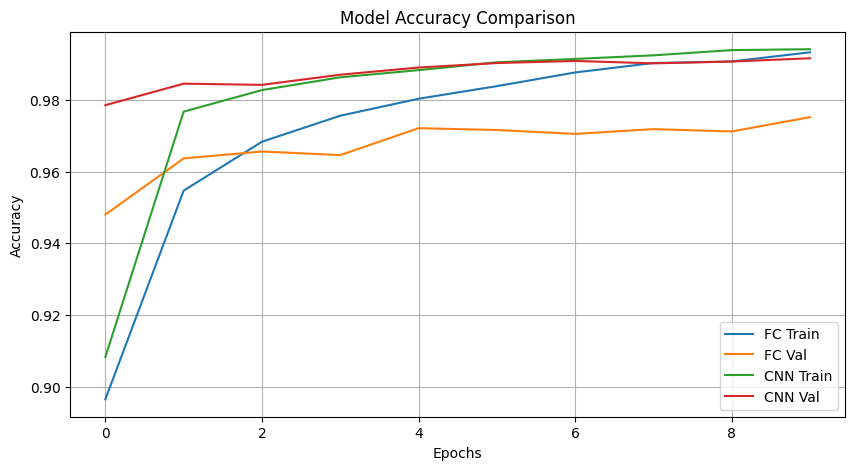

In [6]:
# --- Compare performance ---
print("\n📊 Model Comparison:")
print(f"Fully Connected Network Accuracy: {test_acc_fc:.4f}")
print(f"CNN Accuracy: {test_acc_cnn:.4f}")

# Plot accuracy curves
plt.figure(figsize=(10, 5))
plt.plot(history_fc.history['accuracy'], label='FC Train')
plt.plot(history_fc.history['val_accuracy'], label='FC Val')
plt.plot(history_cnn.history['accuracy'], label='CNN Train')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Val')
plt.title('Model Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


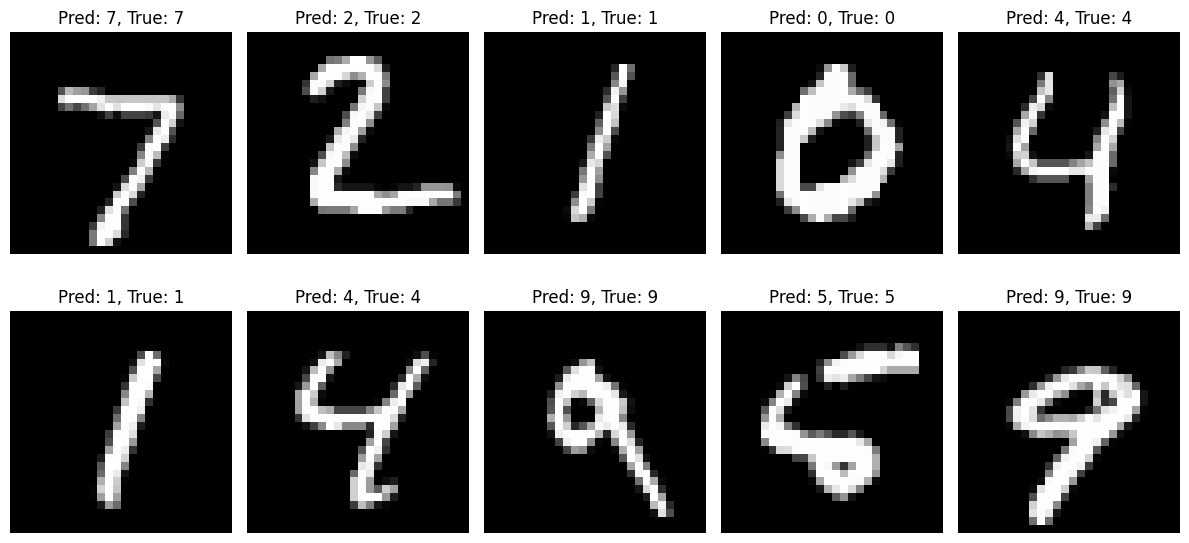

In [7]:
# --- Visualize CNN Predictions ---
preds = cnn_model.predict(X_test_cnn)
pred_labels = np.argmax(preds, axis=1)

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Pred: {pred_labels[i]}, True: {y_test[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


🧾 Summary:
The Fully Connected Network achieved moderate accuracy (97%),
but the Convolutional Neural Network significantly outperformed it (99%)
thanks to its ability to capture spatial patterns through convolutional filters.
CNNs are ideal for image data because they preserve local pixel relationships
and use fewer parameters than fully connected layers.